<a href="https://colab.research.google.com/github/julianresendiz/ds_challenge2_TelecomX/blob/main/Challenge2_TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

## a) Extraer la información desde una URL.

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [3]:
import pandas as pd

In [4]:
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## b) Normalizar la base de datos.

In [5]:
df_customer = pd.json_normalize(df['customer'])
df_phone    = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account  = pd.json_normalize(df['account'])

df_norm = pd.concat([df.drop(['customer','phone','internet','account'], axis=1),
                      df_customer, df_phone, df_internet, df_account], axis=1)
df_norm.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
3228,4508-OEBEY,No,Male,0,Yes,No,31,Yes,No,DSL,...,Yes,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),75.50,2424.45
2566,3580-HYCSP,No,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.30,7966.9
5962,8149-AIQCG,No,Male,0,No,No,39,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),73.15,2730.85
5536,7586-ZATGZ,No,Male,0,No,No,40,Yes,Yes,Fiber optic,...,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,84.90,3369.05
2400,3349-ANQNH,No,Female,1,No,No,59,Yes,Yes,Fiber optic,...,No,Yes,No,Yes,Yes,One year,Yes,Electronic check,99.50,5890
2686,3727-JEZTU,No,Female,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,20.4
89,0137-UDEUO,Yes,Female,0,No,No,3,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.85,63.75
5299,7241-AJHFS,No,Male,0,No,No,32,Yes,Yes,Fiber optic,...,No,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),87.65,2766.4
7228,9940-HPQPG,Yes,Female,0,Yes,No,9,Yes,Yes,Fiber optic,...,Yes,Yes,No,No,No,Month-to-month,No,Bank transfer (automatic),91.75,865.8
663,0943-ZQPXH,No,Male,0,Yes,Yes,44,Yes,No,Fiber optic,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),92.95,4122.9


## c) Revisar los tipos de datos.

In [6]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## d) Definir cuál es la variable objetivo, cuáles se deben eliminar por ser irrelevantes para lo que se necesita determinar y cuáles variables deben cambiar de tipo (por ejemplo, categóricas a numéricas).

### Las variables SeniorCitizen, tenure y Charges.Monthly son las únicas con el tipo de dato correcto.

In [7]:
df_norm['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [8]:
empty_churn_count = df_norm[df_norm['Churn'] == ''].shape[0]
print(f"Número de registros con valor vacío en 'Churn': {empty_churn_count}")

Número de registros con valor vacío en 'Churn': 224


In [29]:
df_norm.describe()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.265370,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.615505,1.222916,0.720006,0.778220,0.777226,0.723555,0.817691,0.821241,0.690473,0.592219,1.315633,64.761692,2283.300441
std,0.441561,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.656039,0.778877,0.796885,0.778472,0.778826,0.795896,0.763212,0.761725,0.833755,0.491457,1.148907,30.090047,2266.771362
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,401.450000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,70.350000,1397.475000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,89.850000,3794.737500
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000


#🔧 Transformación

## a) Eliminar datos vacíos en la variable objetivo o dependiente pues sólo representan 3% de la base de datos.

In [9]:
df_norm = df_norm[df_norm['Churn'] != ''].copy()
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

## b) Mapeos para cambiar datos categóricos a numéricos.

In [10]:
import pandas as pd
import numpy as np

# Ensure 'Churn' column does not contain empty strings before mapping
df_norm = df_norm[df_norm['Churn'] != ''].copy()

# Conversión de variables categóricas a numéricas

# Variable dependiente
df_norm['Churn'] = df_norm['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

# Customer
df_norm['gender'] = df_norm['gender'].map({'Female': 0, 'Male': 1}).astype(int)
df_norm['Partner'] = df_norm['Partner'].map({'No': 0, 'Yes': 1}).astype(int)
df_norm['Dependents'] = df_norm['Dependents'].map({'No': 0, 'Yes': 1}).astype(int)

# Phone
df_norm['PhoneService'] = df_norm['PhoneService'].map({'No': 0, 'Yes': 1}).astype(int)
df_norm['MultipleLines'] = df_norm['MultipleLines'].map({
    'No': 0,
    'Yes': 1,
    'No phone service': 2
}).astype(int)

# Internet
df_norm['InternetService'] = df_norm['InternetService'].map({
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
}).astype(int)

df_norm['OnlineSecurity'] = df_norm['OnlineSecurity'].map({
    'No': 0,
    'Yes': 1,
    'No internet service': 2
}).astype(int)

df_norm['OnlineBackup'] = df_norm['OnlineBackup'].map({
    'No': 0,
    'Yes': 1,
    'No internet service': 2
}).astype(int)

df_norm['DeviceProtection'] = df_norm['DeviceProtection'].map({
    'No': 0,
    'Yes': 1,
    'No internet service': 2
}).astype(int)

df_norm['TechSupport'] = df_norm['TechSupport'].map({
    'No': 0,
    'Yes': 1,
    'No internet service': 2
}).astype(int)

df_norm['StreamingTV'] = df_norm['StreamingTV'].map({
    'No': 0,
    'Yes': 1,
    'No internet service': 2
}).astype(int)

df_norm['StreamingMovies'] = df_norm['StreamingMovies'].map({
    'No': 0,
    'Yes': 1,
    'No internet service': 2
}).astype(int)

# Account
df_norm['Contract'] = df_norm['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}).astype(int)

df_norm['PaperlessBilling'] = df_norm['PaperlessBilling'].map({'No': 0, 'Yes': 1}).astype(int)

df_norm['PaymentMethod'] = df_norm['PaymentMethod'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
}).astype(int)

# Charges

## c) Cambiar la variable `Charges.Total` a tipo `float`.

In [11]:
df_norm['Charges.Total'] = pd.to_numeric(df_norm['Charges.Total'], errors='coerce').astype(float)

In [12]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   int64  
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   int64  
 9   InternetService   7043 non-null   int64  
 10  OnlineSecurity    7043 non-null   int64  
 11  OnlineBackup      7043 non-null   int64  
 12  DeviceProtection  7043 non-null   int64  
 13  TechSupport       7043 non-null   int64  
 14  StreamingTV       7043 non-null   int64  
 15  StreamingMovies   7043 non-null   int64  
 16  Contract          7043 non-null   int64  
 17  

## c) Llenar 11 registros de Charges.Total con la mediana correspondiente.

In [35]:
print("Nulos en Charges.Total:", df_norm['Charges.Total'].isnull().sum())


Nulos en Charges.Total: 11


In [37]:
print(df_norm['Charges.Total'].describe())

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: Charges.Total, dtype: float64


In [38]:
mediana_total = df_norm['Charges.Total'].median()
print("Mediana de Charges.Total:", mediana_total)

Mediana de Charges.Total: 1397.475


In [39]:
df_norm['Charges.Total'] = df_norm['Charges.Total'].fillna(mediana_total).astype(float)

## d) Eliminar columna customerID

In [40]:
if 'customerID' in df_norm.columns:
    df_norm = df_norm.drop('customerID', axis=1)
else:
    print("Column 'customerID' not found. It might have been dropped already.")
df_norm.info()

Column 'customerID' not found. It might have been dropped already.
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   int64  
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-

In [42]:
df_norm.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,0,0,1,1,9,1,0,1,0,1,0,1,1,0,1,1,1,65.6,593.30
1,0,1,0,0,0,9,1,1,1,0,0,0,0,0,1,0,0,1,59.9,542.40
2,1,1,0,0,0,4,1,0,2,0,0,1,0,0,0,0,1,0,73.9,280.85
3,1,1,1,1,0,13,1,0,2,0,1,1,0,1,1,0,1,0,98.0,1237.85
4,1,0,1,1,0,3,1,0,2,0,0,0,1,1,0,0,1,1,83.9,267.40


#📊 Carga y análisis

## a) Distribución de la evasión


### a1) Absoluta

<Axes: xlabel='Churn', ylabel='count'>

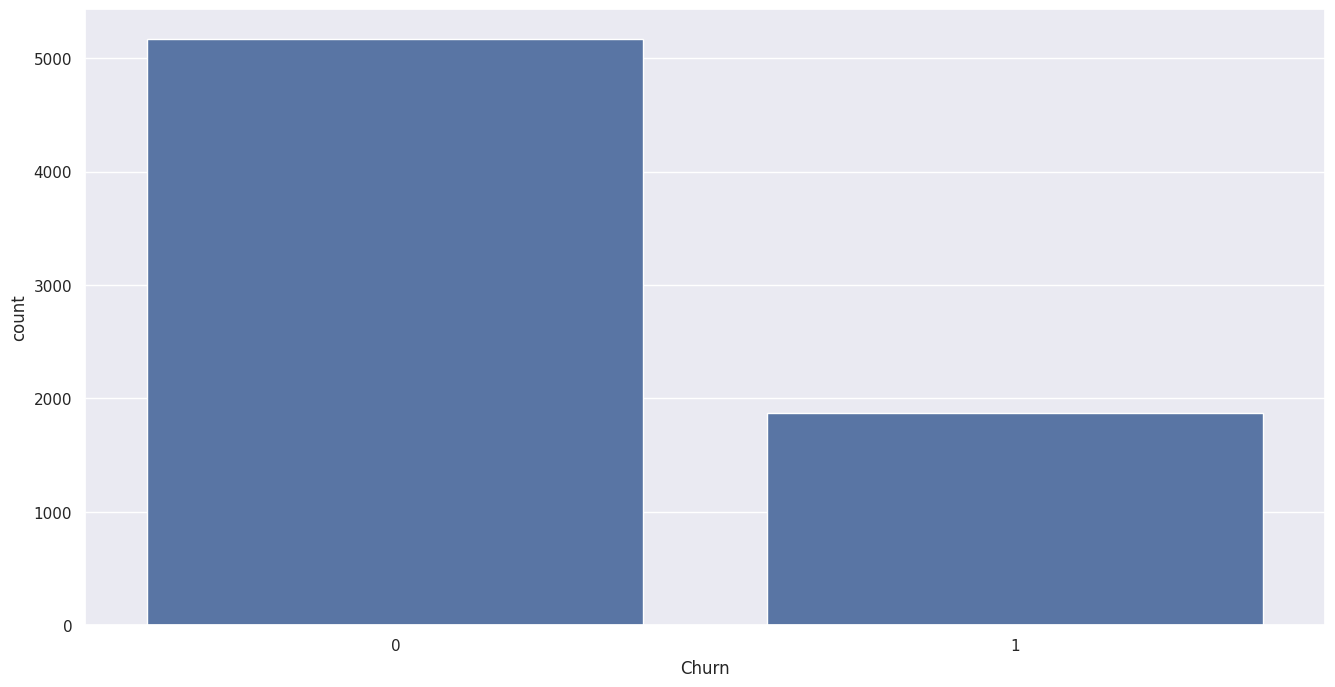

In [43]:
import seaborn as sb
sb.countplot(x='Churn', data = df_norm)

In [44]:
conteo_churn = df_norm['Churn'].value_counts()
print("Conteo de churn:\n", conteo_churn)

Conteo de churn:
 Churn
0    5174
1    1869
Name: count, dtype: int64


### a2) Relativa

In [57]:
porcentaje_churn = df_norm['Churn'].value_counts(normalize=True) * 100
print("\nPorcentaje de churn:\n", porcentaje_churn)


Porcentaje de churn:
 Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


### a3) Por género

In [45]:
df_norm.groupby('gender')['Churn'].value_counts(normalize=True)

gender  Churn
0       0        0.730791
        1        0.269209
1       0        0.738397
        1        0.261603
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

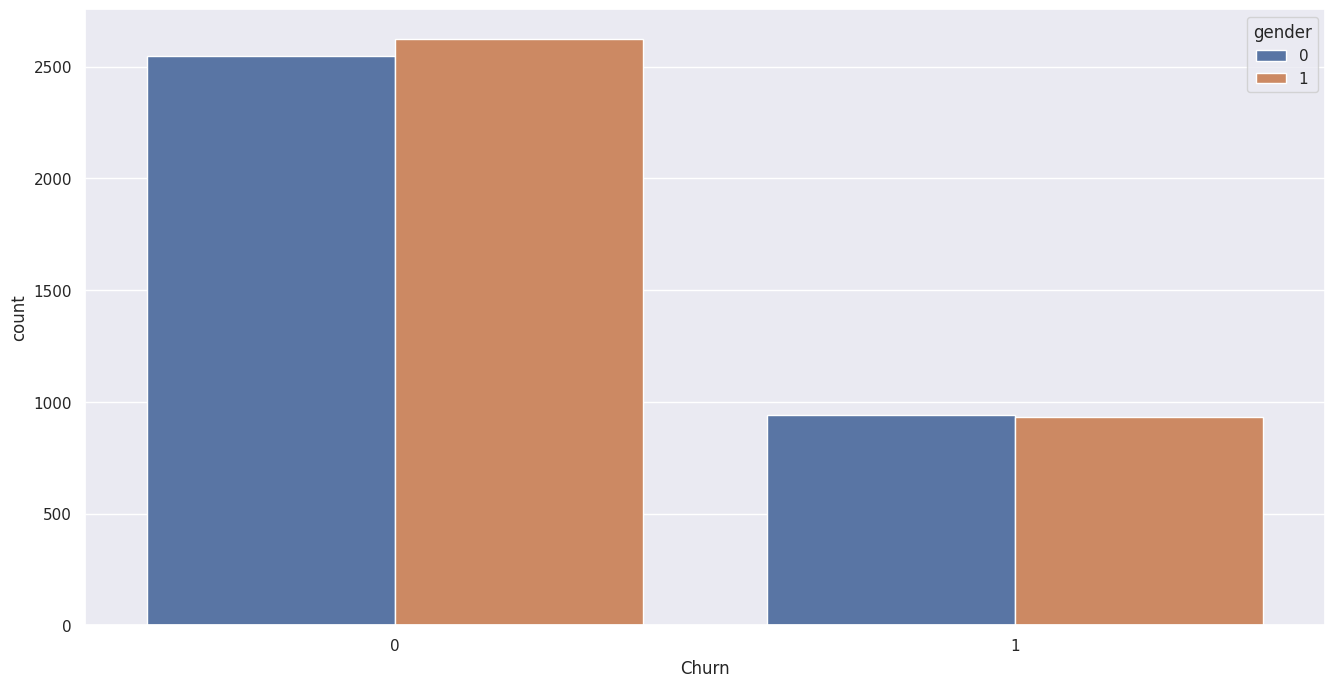

In [58]:
sb.countplot(x='Churn', data = df_norm, hue='gender')

### INSIGHT. No hay diferencias en la cancelación del servicio con base en el género.

## b) Análisis de correlaciones

In [46]:
df_norm.corr()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
Churn,1.000000,-0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.019423,0.316846,-0.332819,-0.291449,-0.281465,-0.329852,-0.205742,-0.207256,-0.396713,0.191825,-0.262818,0.193356,-0.199037
gender,-0.008612,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.000485,-0.010380,-0.003429,-0.002032,0.005092,0.000985,0.001156,-0.000191,0.000126,-0.011754,-0.005209,-0.014569,-0.000002
SeniorCitizen,0.150889,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.099883,0.259390,-0.210897,-0.152780,-0.157095,-0.223770,-0.130130,-0.120802,-0.142554,0.156530,-0.093704,0.220173,0.102652
Partner,-0.150448,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,0.090981,-0.000132,0.081850,0.087055,0.094451,0.069072,0.080127,0.075779,0.294806,-0.014877,0.133115,0.096848,0.318364
Dependents,-0.164221,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.016875,-0.179631,0.190523,0.162445,0.156439,0.180832,0.140395,0.125820,0.243187,-0.111377,0.123844,-0.113890,0.063593
tenure,-0.352229,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.242279,0.033230,0.145298,0.178651,0.178649,0.144459,0.136145,0.140781,0.671607,0.006152,0.340305,0.247900,0.825464
PhoneService,0.011942,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.691070,0.093720,0.125353,0.150338,0.138755,0.123350,0.171538,0.165205,0.002247,0.016505,-0.004070,0.247398,0.113013
MultipleLines,0.019423,-0.000485,0.099883,0.090981,-0.016875,0.242279,-0.691070,1.000000,0.174989,-0.235021,-0.210372,-0.200463,-0.232155,-0.202414,-0.195815,0.078613,0.108230,0.030659,0.146153,0.250961
InternetService,0.316846,-0.010380,0.259390,-0.000132,-0.179631,0.033230,0.093720,0.174989,1.000000,-0.764943,-0.686403,-0.682448,-0.760985,-0.617704,-0.620005,-0.290189,0.378108,-0.178137,0.905491,0.428301
OnlineSecurity,-0.332819,-0.003429,-0.210897,0.081850,0.190523,0.145298,0.125353,-0.235021,-0.764943,1.000000,0.751661,0.749040,0.791225,0.701976,0.704984,0.389978,-0.334003,0.213800,-0.621227,-0.153596


<Axes: >

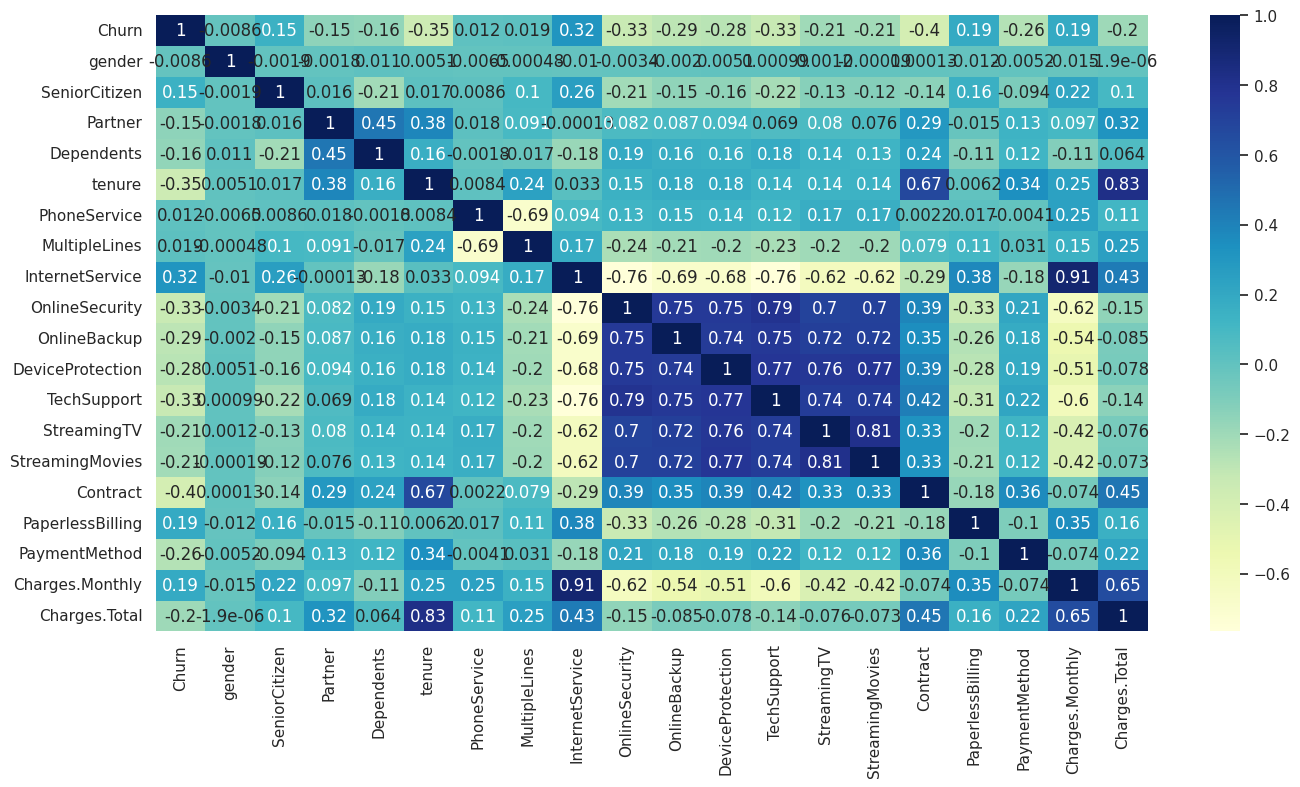

In [47]:
sb.set(rc={'figure.figsize':(16,8)})
sb.heatmap(df_norm.corr(), annot = True, cmap = 'YlGnBu')

In [48]:
df_norm.corr()['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
InternetService,0.316846
Charges.Monthly,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
MultipleLines,0.019423
PhoneService,0.011942
gender,-0.008612
Partner,-0.150448
Dependents,-0.164221


## c) Profundizando en las correlaciones con mayor relación con el churn.

### CON CORRELACIÓN POSITIVA

#### c1) Internet Service

<Axes: xlabel='Churn', ylabel='count'>

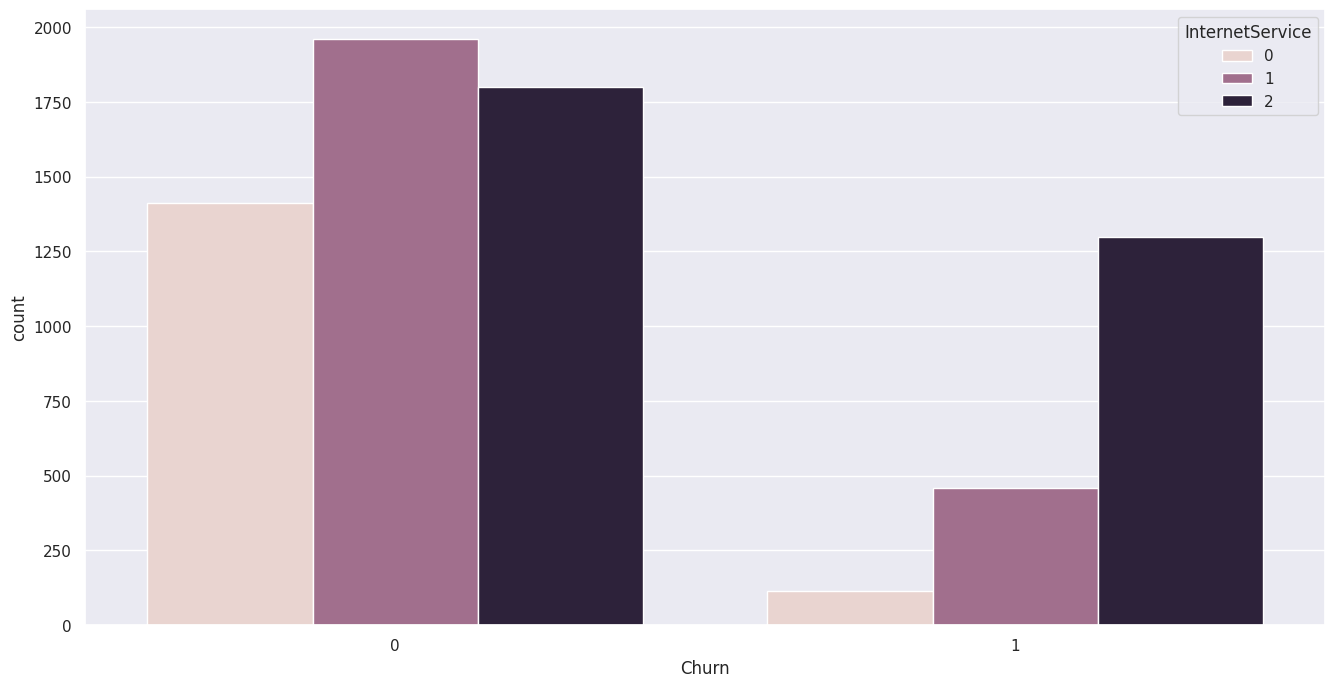

In [49]:
sb.countplot(x='Churn', data = df_norm, hue='InternetService')

### INSIGHT. Las personas que cuentan con servicio de internet, en particular las que tienen contratado fibra óptica, son los más propensos a cancelar el servicio.

#### c2) Charges.Monthly

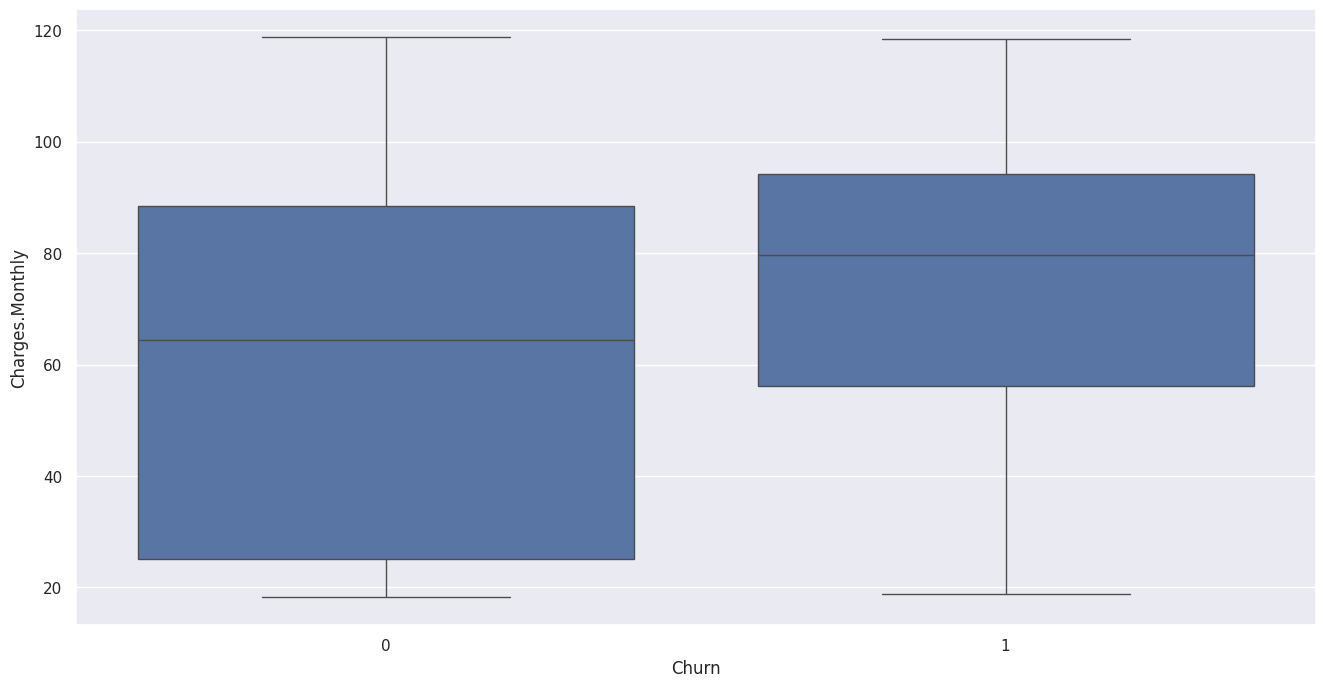

In [59]:
import matplotlib.pyplot as plt

sb.boxplot(x='Churn', y='Charges.Monthly', data=df_norm)
plt.show()


### INSIGHT. Los clientes que abandonan (churn = 1) tienen en promedio cargos mensuales más altos que los que no abandonan (churn = 0).


#### c3) Paperless Billing

<Axes: xlabel='Churn', ylabel='count'>

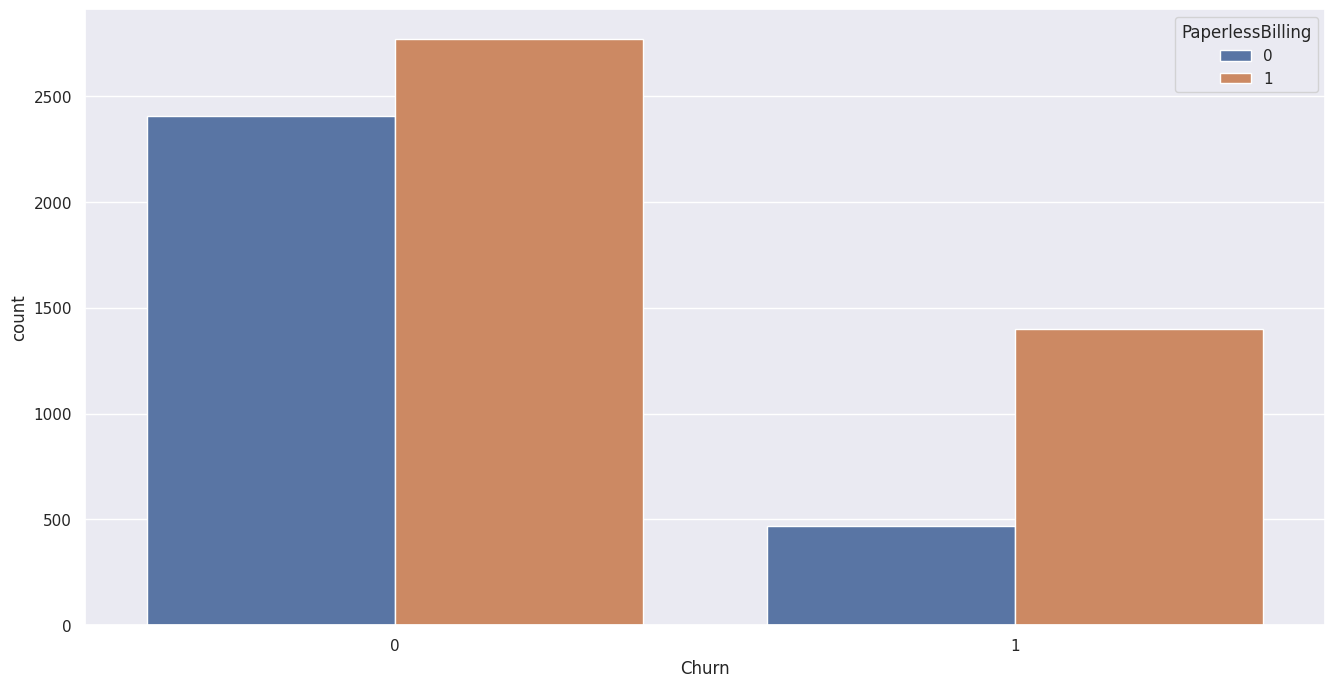

In [51]:
sb.countplot(x='Churn', data = df_norm, hue='PaperlessBilling')

### INSIGHT. Las personas que reciben su factura vía electrónica son propensas a cancelar el servicio debido quizás a que son competentes digitalmente y se les facilita comparar otras opciones más asequibles.

#### c4) Senior citizen

<Axes: xlabel='Churn', ylabel='count'>

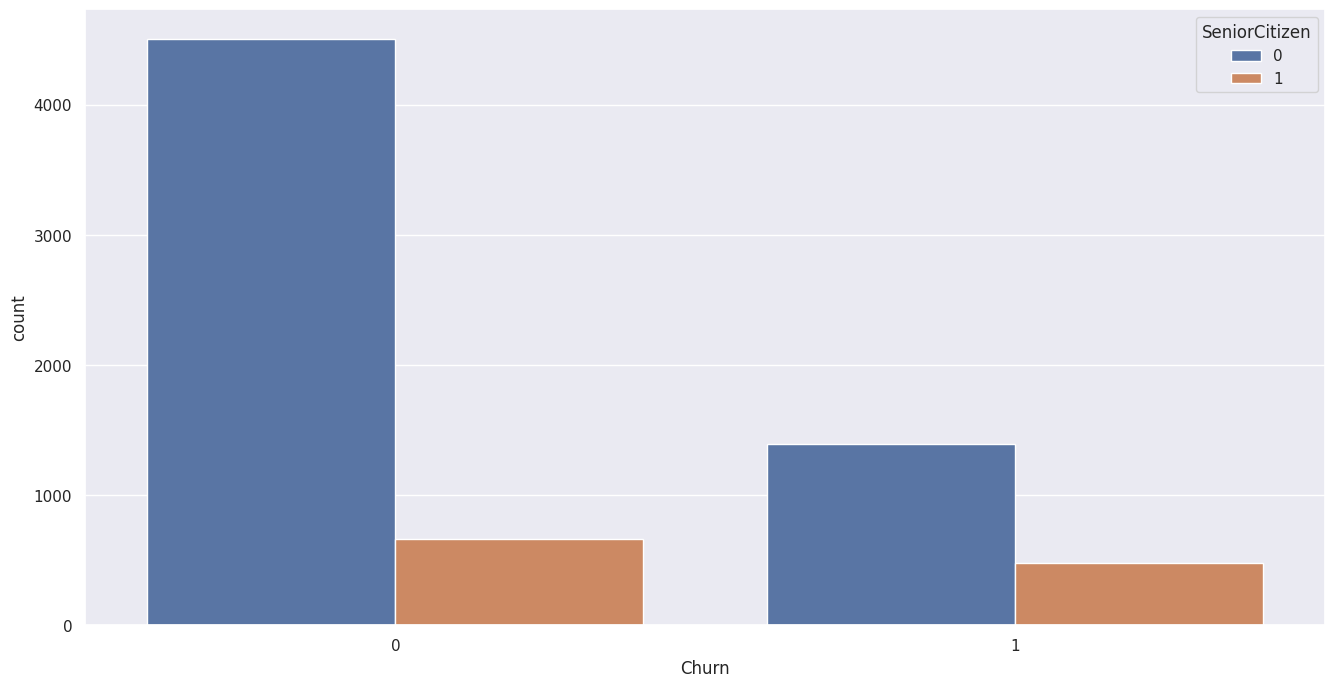

In [52]:
sb.countplot(x='Churn', data = df_norm, hue='SeniorCitizen')

In [53]:
df_norm.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)

SeniorCitizen  Churn
0              0        0.763938
               1        0.236062
1              0        0.583187
               1        0.416813
Name: proportion, dtype: float64

### INSIGHT. La gráfica no es determinante, pero con la tabla se puede ver que una gran proporción de personas con 65 años o más son propensos a cancelar el servicio.

### CON CORRELACIÓN NEGATIVA

#### c5) Contract

<Axes: xlabel='Churn', ylabel='count'>

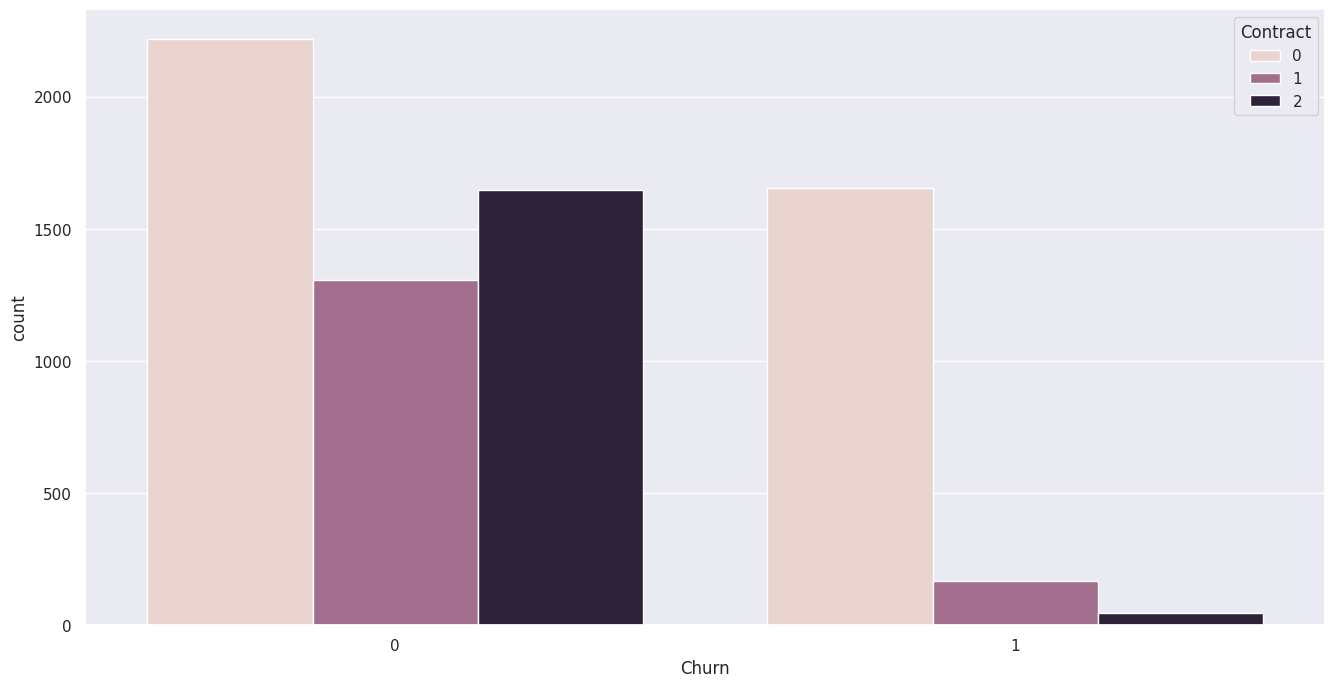

In [54]:
sb.countplot(x='Churn', data = df_norm, hue='Contract')

### INSIGHT. La gráfica muestra que los clientes con un contrato de tipo mes a mes son más propensos a cancelar el servicio.

#### c6) Tenure

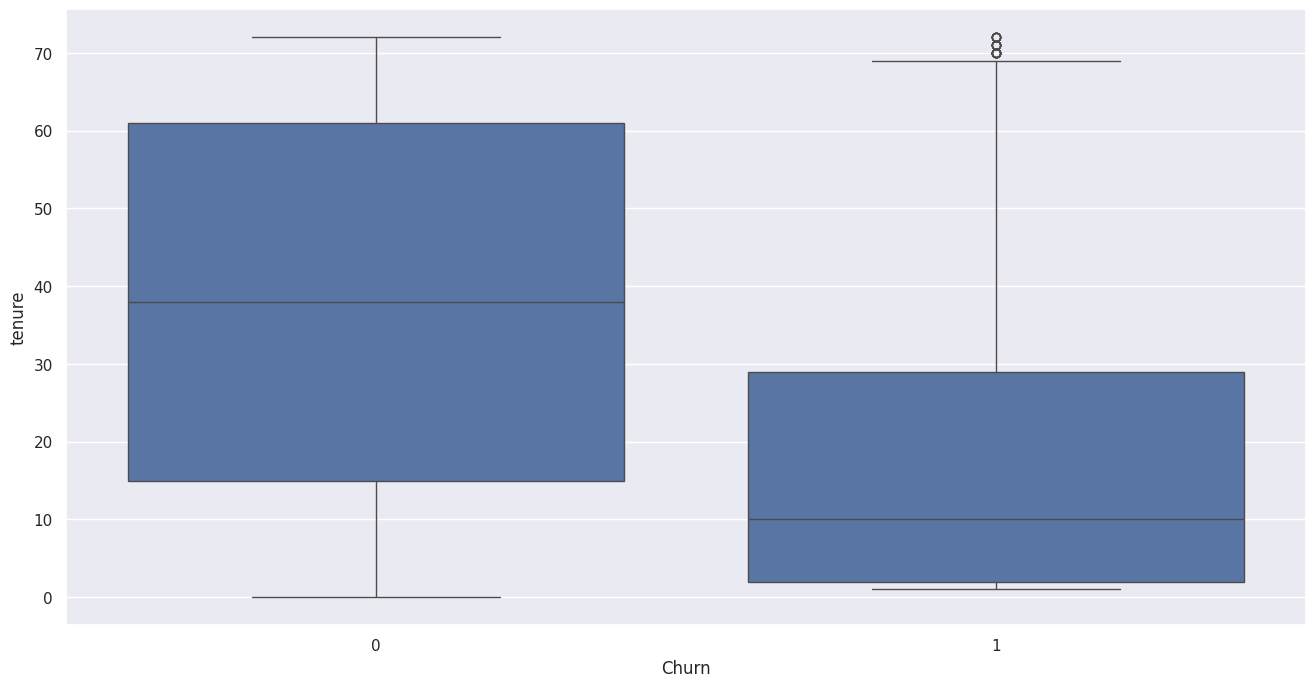

In [55]:
sb.boxplot(x='Churn', y='tenure', data=df_norm)
plt.show()

### INSIGHT. Los boxplot muestran que los clientes con menor tiempo contractual con los servicios son más propensos a dejar la empresa.

#### c7) Online security y otros servicios

<Axes: xlabel='Churn', ylabel='count'>

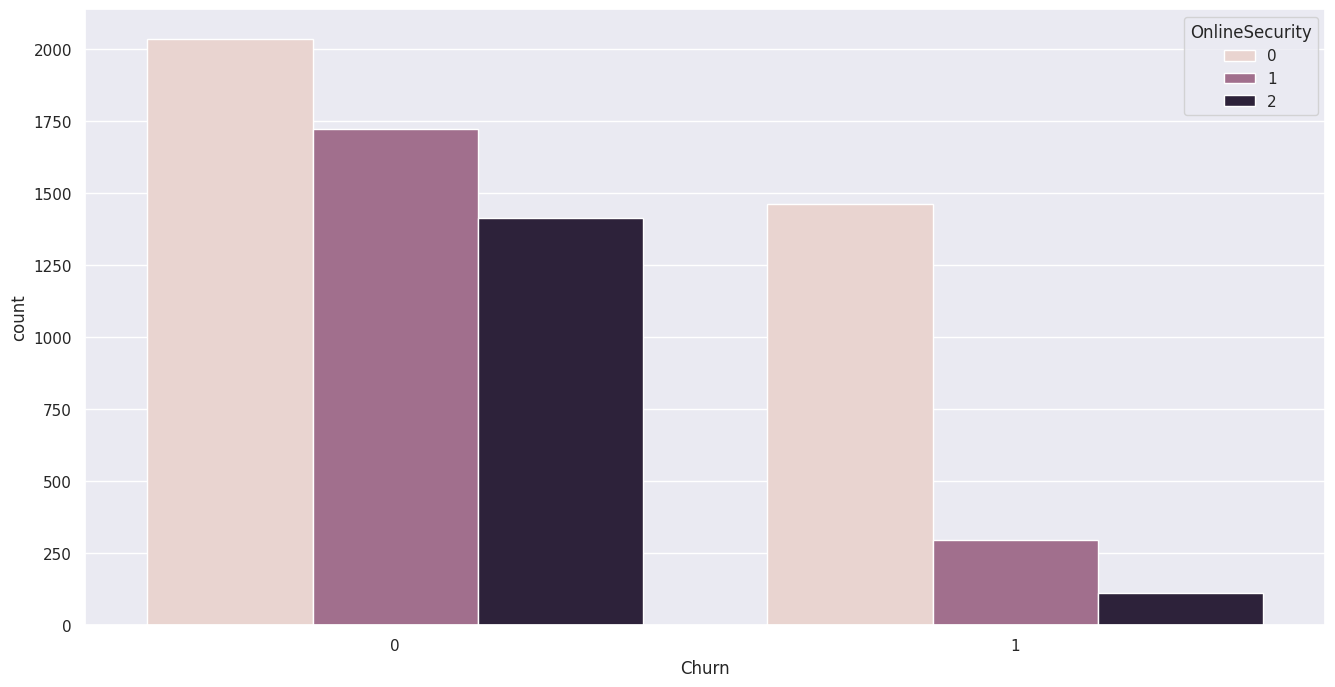

In [56]:
sb.countplot(x='Churn', data = df_norm, hue='OnlineSecurity')

### Con respecto a la correlación negativa y la contratación de diferentes servicios, gráficos similares al anterior muestran que aquellos que tienen más servicios contratados son menos propensos a dejar la empresa.

#📄Informe final

## 🔹 Introducción: Explica el objetivo del análisis y el problema de evasión de clientes (Churn).

### La empresa TelecomX requiere un análisis de la base de datos de sus clientes para *ajustar sus estrategias comerciales* con el fin de **reducir la tasa de deserción de clientes** que actualmente es de **26%**.

##🔹 Limpieza y Tratamiento de Datos: Describe los pasos realizados para importar, limpiar y procesar los datos.

### Se usó `Python` y las librerías `Pandas`, `NumPy`, `Matplotlib` y `Seaborn` para importar, limpiar y procesar los datos provenientes en formato `json`.

### Lo primero fue normalizar la base de datos pues contenía información anidada. Luego se revisó el tipo de datos para determinar cuál es la variable objetivo, cuál variable es irrelevante para el análisis y se debe eliminar y establecer qué variables deben cambiar de tipo de dato (por ejemplo, categóricas por numéricas).

### Después se verifican valores nulos, y aunque en un primer momento parece que no había, en realidad dos variables `Churn` y `Charges.Total` tenían registros inconsistentes.

### Las inconsistencias de la primera variable se eliminan pues representan sólo 3% de la BBDD y las inconsistencias de la segunda variable que sólo son 11 registros se completan con la mediana del valor correspondiente.

### La variable customerID no es relevante para el análisis por lo que se elimina del DataFrame.





## 🔹 Análisis Exploratorio de Datos: Presenta los análisis realizados, incluyendo gráficos y visualizaciones para identificar patrones.

### Se determina la distribución del Churn de forma absoluta y relativa. Se establece una tasa actual de 26% de deserción.

### Se descarta que la deserción se deba al género.

### El análisis de correlaciones muestra que las principales variables con correlación positiva son `InternetService`, `Charges.Monthly`, `PaperlessBilling` y `SeniorCitizen`. Por su parte, las principales variables con correlación negativa son `Contract`, `Tenure` y la contratación de diversos servicios ligados al internet y al `PaymentMethod`.

## 🔹 Conclusiones e Insights: Resume los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.

### Se determina que la variable más influyente en relación con la deserción del servicio es `Contract`. Al ser una correlación negativo, esto indica que los clientes con contratos mensuales tienen tasas de abandono mucho más altas que los que firman contratos anuales o de dos años.

### `Tenure` también es crítica con correlación negativa, es decir, que los clientes con pocos meses de contrato suelen tener mayor probabilidad de abandonar.

### Además, la contratación de servicios adicionales como `OnlineSecurity` u `OnlineBackup` son indicadores de mayor fidelización. Su ausencia suele correlacionarse con mayor abandono.

### Con respecto a correlaciones positivas, la variable preponderante es `InternetService` y destaca que los clientes que contratan *Fibra óptica* son más propensos a abandonar el servicio.

### `Charges.Monthly` explica que los clientes con facturas mensuales elevadas abandonen el servico.

### `PaperlessBilling` sugiere que los clientes digitalmente competentes cancelan con mayor frecuencia debido a que encuentran con facilidad otras opciones en servicios de telefonía e internet.

### Finalmente, `SeniorCitizen` muestra que clientes de 65 años o más abandonan con mayor frecuencia el servicio, debido quizás a su menor necesidad y uso de servicios digitales.

##🔹 Recomendaciones: Ofrece sugerencias estratégicas basadas en tu análisis.

### Con el fin de reducir la tasa de deserción de los servicios, la empresa debería:

- Impulsar contratos de largo plazo mediante ajustes estratégicos de precios que hagan atractiva la permanencia.
- Diseñar paquetes integrales que incluyan internet, seguridad online y entretenimiento, reforzando la retención con descuentos específicos para clientes sensibles a cargos elevados.
- Promover métodos de pago automáticos para simplificar la experiencia y aumentar la fidelidad.
- Brindar soporte personalizado a adultos mayores, adaptando la atención a sus necesidades para reducir la deserción.
